In [2]:
import matplotlib.pyplot as plt
import seaborn as sns

# Machine learning libraries
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import cross_val_score, GridSearchCV, StratifiedKFold
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, VotingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
import lightgbm as lgb
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import pandas as pd
import optuna


f:\Anaconda\lib\site-packages\pandas\core\arrays\masked.py:60: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


In [15]:
print("Loading data...")
train_df = pd.read_csv('train.csv')
test_df = pd.read_csv('test.csv')
train = train_df.copy()
test= test_df.copy()
print(f"Training data shape: {train.shape}")
print(f"Testing data shape: {test.shape}")

Loading data...
Training data shape: (891, 12)
Testing data shape: (418, 11)


In [16]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [3]:
# Display first few rows of training data
print("First five rows of the training data:")
display(train.head())

# Display information about the dataset
print("\nDataset Information:")
train.info()

# Check for missing values
print("\nMissing values in training data:")
display(train.isnull().sum())

# Statistical summary
print("\nStatistical summary of numeric features:")
display(train.describe())

First five rows of the training data:


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S



Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB

Missing values in training data:


PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64


Statistical summary of numeric features:


,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [4]:
train['Name'].nunique()

891

In [5]:
train.drop(columns=['PassengerId', 'Name', 'Ticket', 'Cabin'], axis=1, inplace=True)
test.drop(columns= ['PassengerId', 'Name', 'Ticket', 'Cabin'], axis=1, inplace= True)

In [6]:
train['Age'].fillna(train['Age'].median(), inplace=True)
train['Embarked'].fillna(train['Embarked'].mode()[0], inplace=True)

C:\Users\qli97\AppData\Local\Temp\ipykernel_47288\648336700.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  train['Age'].fillna(train['Age'].median(), inplace=True)
C:\Users\qli97\AppData\Local\Temp\ipykernel_47288\648336700.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

F

In [7]:
print(train.isnull().sum())

Survived    0
Pclass      0
Sex         0
Age         0
SibSp       0
Parch       0
Fare        0
Embarked    0
dtype: int64


In [8]:
test['Age'].fillna(test['Age'].median(), inplace=True)
test['Fare'].fillna(test['Fare'].median(), inplace=True)

C:\Users\qli97\AppData\Local\Temp\ipykernel_47288\1359732817.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  test['Age'].fillna(test['Age'].median(), inplace=True)
C:\Users\qli97\AppData\Local\Temp\ipykernel_47288\1359732817.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

F

In [9]:
train['Survived'].value_counts()

Survived
0    549
1    342
Name: count, dtype: int64

<Axes: xlabel='Survived', ylabel='count'>

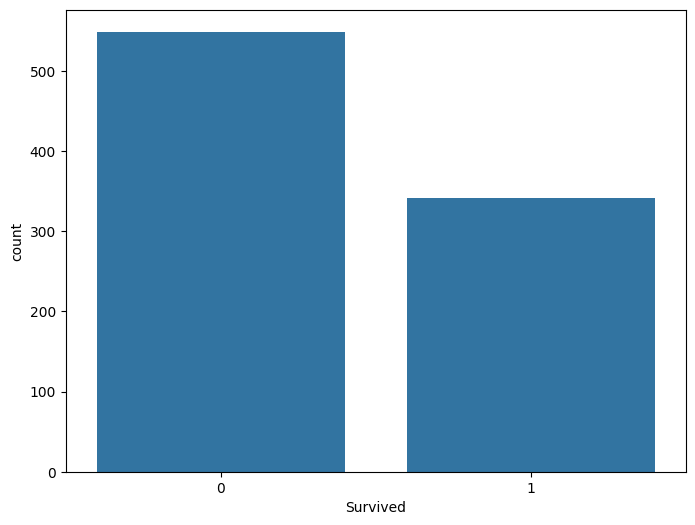

In [10]:
plt.figure(figsize=(8,6))
sns.countplot(x='Survived', data= train)

<Axes: xlabel='Survived', ylabel='count'>

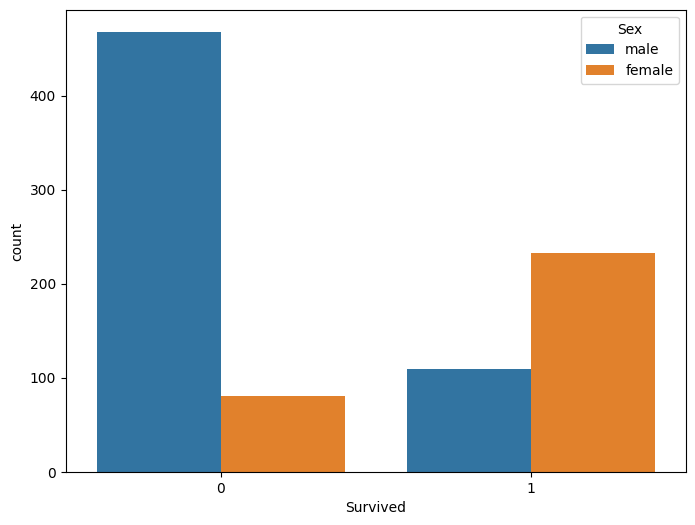

In [11]:
plt.figure(figsize=(8,6))
sns.countplot(x='Survived', hue='Sex', data= train)

<Axes: xlabel='Survived'>

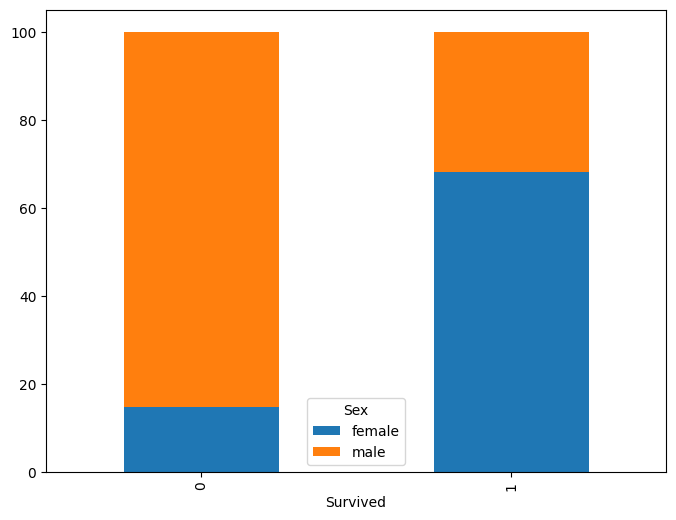

In [12]:
sur_p = train.groupby(['Survived', 'Sex']).size().unstack(fill_value=0)
sur_p_percent = sur_p.div(sur_p.sum(axis=1), axis=0) * 100
sur_p_percent.plot(kind='bar', stacked=True, figsize=(8,6))

<Axes: xlabel='Age', ylabel='Count'>

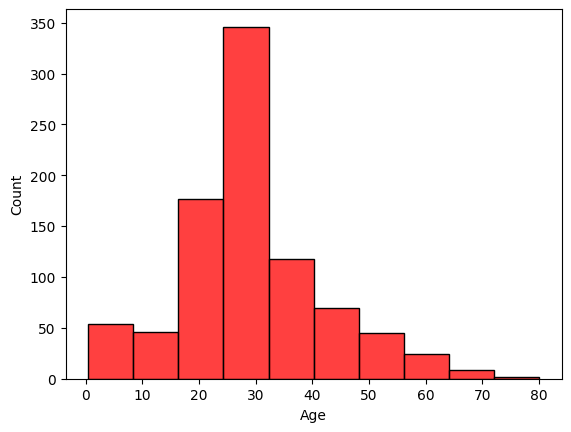

In [13]:
sns.histplot(x='Age', data=train, bins=10, color='red')

<Axes: xlabel='Pclass', ylabel='Fare'>

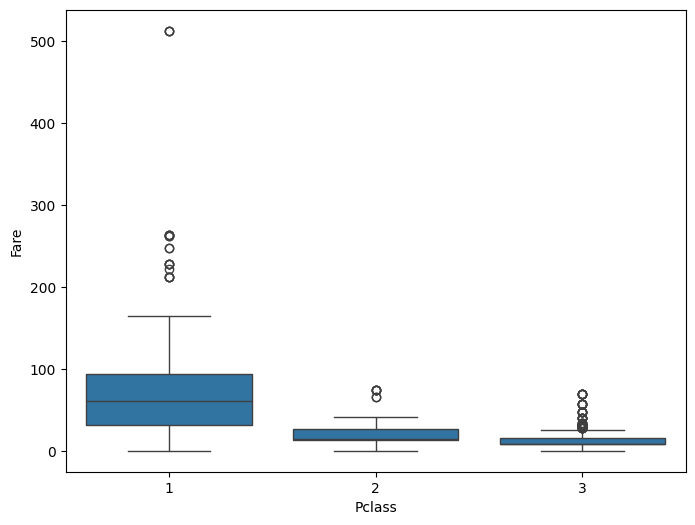

In [14]:
plt.figure(figsize=(8,6))
sns.boxplot(x='Pclass', y= 'Fare', data= train)

In [15]:
cols= ['Age', 'SibSp', 'Parch', 'Fare']

train[cols]= train[cols].clip(lower= train[cols].quantile(0.15), upper= train[cols].quantile(0.85), axis=1)

train.drop(columns=['Parch'], axis=1, inplace=True)

In [16]:
train.select_dtypes(include='number').corr()

,Survived,Pclass,Age,SibSp,Fare
Survived,1.000000,-0.338481,-0.023878,0.115867,0.314835
Pclass,-0.338481,1.000000,-0.333720,-0.076009,-0.726347
Age,-0.023878,-0.333720,1.000000,-0.079553,0.167626
SibSp,0.115867,-0.076009,-0.079553,1.000000,0.394485
Fare,0.314835,-0.726347,0.167626,0.394485,1.000000


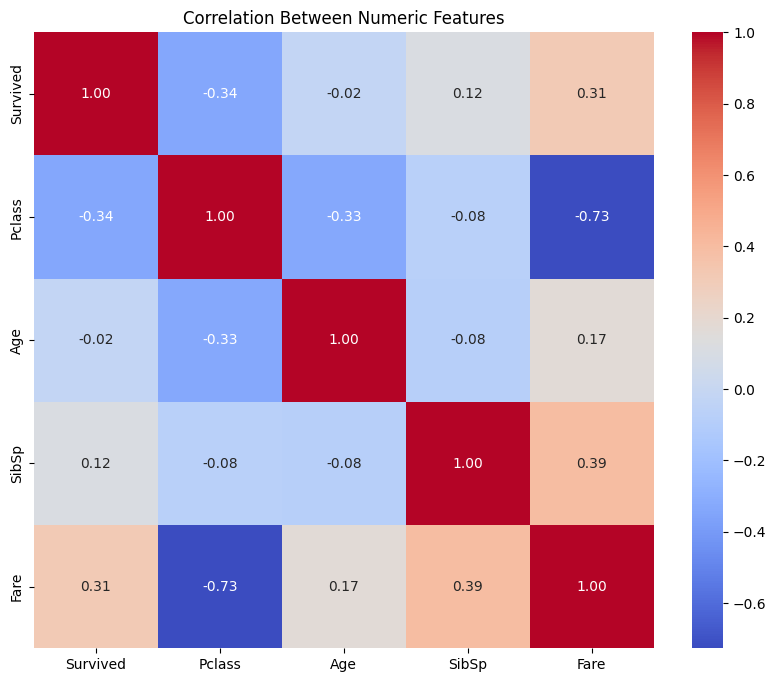

In [17]:
# Correlation heatmap of numeric features
plt.figure(figsize=(10, 8))
numeric_data = train.select_dtypes(include='number')
correlation = numeric_data.corr()
sns.heatmap(correlation, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Between Numeric Features')
plt.savefig('correlation_heatmap.png')
plt.show()


<Axes: >

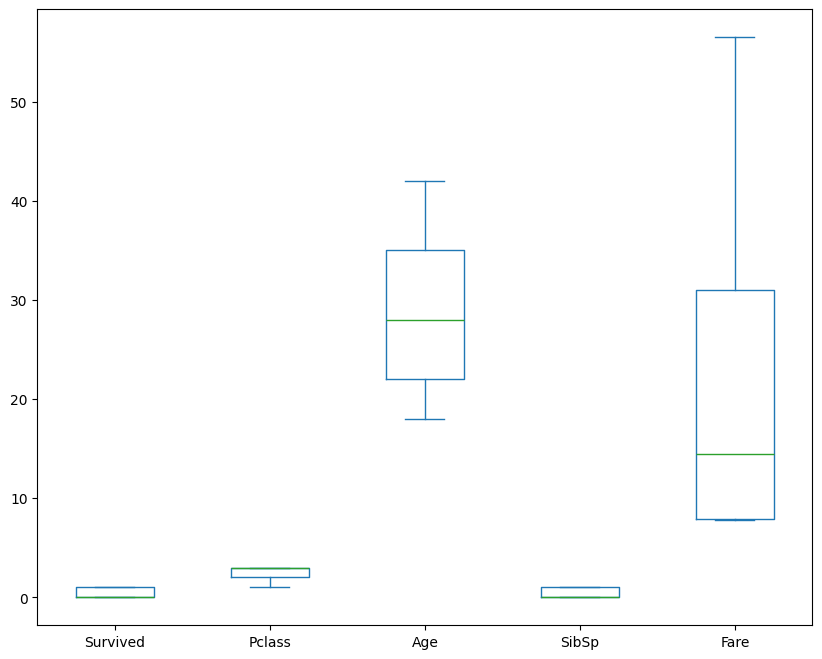

In [18]:
train.plot(kind='box', figsize= (10,8)) 

In [19]:
test[cols]= test[cols].clip(lower= test[cols].quantile(0.15), upper= test[cols].quantile(0.85), axis=1)

test.drop(columns=['Parch'], axis=1, inplace=True)

In [20]:
train= pd.get_dummies(train, columns=['Pclass', 'Sex', 'Embarked' ], drop_first= True)

test= pd.get_dummies(test, columns=['Pclass', 'Sex', 'Embarked' ], drop_first= True)

In [21]:
train.head()

,Survived,Age,SibSp,Fare,Pclass_2,Pclass_3,Sex_male,Embarked_Q,Embarked_S
0,0,22.0,1,7.7500,False,True,True,False,True
1,1,38.0,1,56.4958,False,False,False,False,False
2,1,26.0,0,7.9250,False,True,False,False,True
3,1,35.0,1,53.1000,False,False,False,False,True
4,0,35.0,0,8.0500,False,True,True,False,True


In [22]:
X_train= train.iloc[:, 1:]
y_train= train.iloc[:,0].values.reshape(-1,1)

X_test= test

In [23]:
from sklearn.preprocessing import StandardScaler
ss= StandardScaler()
features= ['Age', 'SibSp', 'Fare']

X_train[features]= ss.fit_transform(X_train[features])
X_test[features]= ss.fit_transform(X_test[features])

In [24]:
from sklearn.linear_model import LogisticRegression

clf= LogisticRegression()

clf.fit(X_train, y_train.ravel())

predictions= clf.predict(X_test)

In [25]:
print(clf.score(X_train, y_train))

0.792368125701459


In [26]:
cross_val_score(clf, X_train, y_train.ravel(), cv= 5).mean()

0.7834097043500095

In [27]:
# Ensure test_df is defined and available
submission = pd.DataFrame({'PassengerId': test_df['PassengerId'], 'Survived': predictions})

# Display the first few rows of the submission dataframe
print(submission.head())

   PassengerId  Survived
0          892         0
1          893         0
2          894         0
3          895         0
4          896         1


In [28]:
submission.to_csv('submission.csv', index= False)

In [29]:
param_grid = {
    'n_estimators': [100, 200],
    'learning_rate': [0.01, 0.1]
}

In [31]:
import lightgbm
model_cls = lightgbm.LGBMClassifier()
results = GridSearchCV(estimator=model_cls, param_grid=param_grid, scoring='accuracy', cv=5, verbose=1, n_jobs=-1)

In [32]:
results.fit(X_train, y_train.ravel())

Fitting 5 folds for each of 4 candidates, totalling 20 fits
[LightGBM] [Info] Number of positive: 342, number of negative: 549
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000176 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 129
[LightGBM] [Info] Number of data points in the train set: 891, number of used features: 8
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.383838 -> initscore=-0.473288
[LightGBM] [Info] Start training from score -0.473288
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [War

GridSearchCV(cv=5, estimator=LGBMClassifier(), n_jobs=-1,
             param_grid={'learning_rate': [0.01, 0.1],
                         'n_estimators': [100, 200]},
             scoring='accuracy', verbose=1)

In [33]:
display(results.best_params_)

{'learning_rate': 0.1, 'n_estimators': 100}

In [34]:
model = display(results.best_estimator_)

LGBMClassifier()

In [35]:
display(results.best_score_)

0.8282907538760906

In [36]:

import optuna
from sklearn.model_selection import cross_val_score, StratifiedKFold

# Objective function for Optuna
def objective(trial):
    param = {
        "objective": "binary",
        "metric": "binary_error",
        "verbosity": -1,
        "boosting_type": "gbdt",
        "feature_pre_filter": False,
        "lambda_l1": trial.suggest_float("lambda_l1", 1e-8, 10.0, log=True),
        "lambda_l2": trial.suggest_float("lambda_l2", 1e-8, 10.0, log=True),
        "num_leaves": trial.suggest_int("num_leaves", 2, 256),
        "feature_fraction": trial.suggest_float("feature_fraction", 0.4, 1.0),
        "bagging_fraction": trial.suggest_float("bagging_fraction", 0.4, 1.0),
        "bagging_freq": trial.suggest_int("bagging_freq", 1, 7),
        "min_child_samples": trial.suggest_int("min_child_samples", 5, 100),
    }

    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    scores = cross_val_score(
        lgb.LGBMClassifier(**param),
        X_train, y_train,
        scoring="accuracy",
        cv=cv,
        n_jobs=-1
    )

    return 1.0 - scores.mean()  # minimize error (maximize accuracy)

# Run Optuna optimization
study = optuna.create_study(direction="minimize")
study.optimize(objective, n_trials=50)

# Show best trial
print("Best trial:")
trial = study.best_trial
print(f"  Accuracy: {1 - trial.value:.4f}")
print("  Best hyperparameters: ")
for key, value in trial.params.items():
    print(f"    {key}: {value}")

[I 2025-04-25 13:53:39,511] A new study created in memory with name: no-name-78f75115-850f-4eae-bb31-6d4f6ba0dd3a
[I 2025-04-25 13:53:39,623] Trial 0 finished with value: 0.18183415981419881 and parameters: {'lambda_l1': 5.019474159594712e-07, 'lambda_l2': 0.03502070626263435, 'num_leaves': 109, 'feature_fraction': 0.5673818441468748, 'bagging_fraction': 0.7075419934832593, 'bagging_freq': 3, 'min_child_samples': 83}. Best is trial 0 with value: 0.18183415981419881.
[I 2025-04-25 13:53:39,746] Trial 1 finished with value: 0.20426213043751174 and parameters: {'lambda_l1': 0.002047350382076132, 'lambda_l2': 0.00012738674019721917, 'num_leaves': 103, 'feature_fraction': 0.4946026063658311, 'bagging_fraction': 0.547146605449432, 'bagging_freq': 5, 'min_child_samples': 95}. Best is trial 0 with value: 0.18183415981419881.
[I 2025-04-25 13:53:39,996] Trial 2 finished with value: 0.17845709622748096 and parameters: {'lambda_l1': 0.018308311357479793, 'lambda_l2': 1.8014476737546417e-05, 'num_

Best trial:
  Accuracy: 0.8249
  Best hyperparameters: 
    lambda_l1: 0.0003392025677815652
    lambda_l2: 0.00029286825920517116
    num_leaves: 90
    feature_fraction: 0.6524374524482556
    bagging_fraction: 0.5468210179145163
    bagging_freq: 5
    min_child_samples: 12


In [37]:
all_df = pd.concat([train_df, test_df], axis=0)
all_df["set"] = "train"
all_df.loc[all_df.Survived.isna(), "set"] = "test"

In [38]:
all_df["Family Size"] = all_df["SibSp"] + all_df["Parch"] + 1
all_df["Age Interval"] = 0.0
all_df.loc[ all_df['Age'] <= 16, 'Age Interval']  = 0
all_df.loc[(all_df['Age'] > 16) & (all_df['Age'] <= 32), 'Age Interval'] = 1
all_df.loc[(all_df['Age'] > 32) & (all_df['Age'] <= 48), 'Age Interval'] = 2
all_df.loc[(all_df['Age'] > 48) & (all_df['Age'] <= 64), 'Age Interval'] = 3
all_df.loc[ all_df['Age'] > 64, 'Age Interval'] = 4
all_df['Fare Interval'] = 0.0
all_df.loc[ all_df['Fare'] <= 7.91, 'Fare Interval'] = 0
all_df.loc[(all_df['Fare'] > 7.91) & (all_df['Fare'] <= 14.454), 'Fare Interval'] = 1
all_df.loc[(all_df['Fare'] > 14.454) & (all_df['Fare'] <= 31), 'Fare Interval']   = 2
all_df.loc[ all_df['Fare'] > 31, 'Fare Interval'] = 3
all_df["Sex_Pclass"] = all_df.apply(lambda row: row['Sex'][0].upper() + "_C" + str(row["Pclass"]), axis=1)
def get_deck(text):
    try:
        return text[0]
    except Exception as ex:
        return "Unknown"
    
all_df["Deck"] = all_df["Cabin"].apply(lambda x: get_deck(x))

In [39]:
def parse_names(row):
    try:
        text = row["Name"]
        split_text = text.split(",")
        family_name = split_text[0]
        next_text = split_text[1]
        split_text = next_text.split(".")
        title = (split_text[0] + ".").lstrip().rstrip()
        next_text = split_text[1]
        if "(" in next_text:
            split_text = next_text.split("(")
            given_name = split_text[0]
            maiden_name = split_text[1].rstrip(")")
            return pd.Series([family_name, title, given_name, maiden_name])
        else:
            given_name = next_text
            return pd.Series([family_name, title, given_name, None])
    except Exception as ex:
        print(f"Exception: {ex}")
    
all_df[["Family Name", "Title", "Given Name", "Maiden Name"]] = all_df.apply(lambda row: parse_names(row), axis=1)

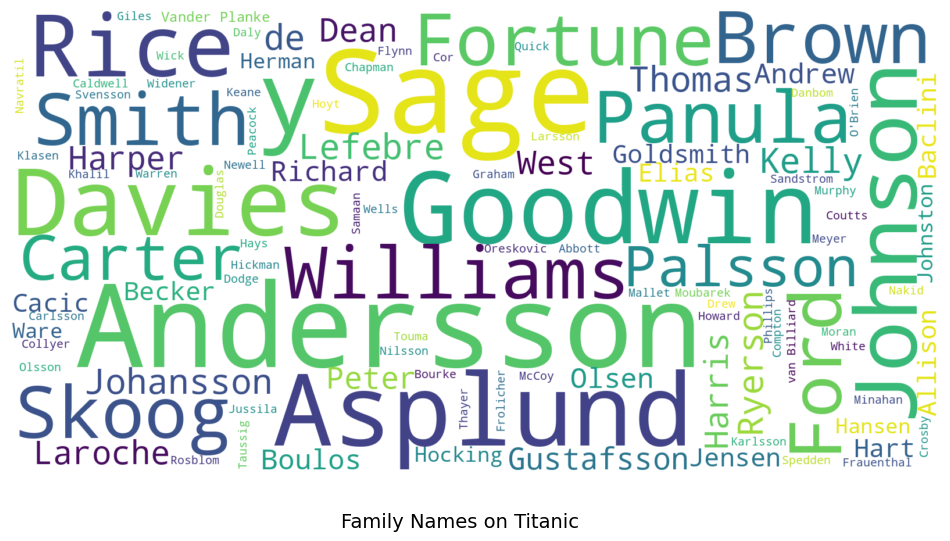

In [40]:
from wordcloud import WordCloud, STOPWORDS
stopwords = set(STOPWORDS)

def show_wordcloud(data, mask=None, title=""):
    text = " ".join(t for t in data.dropna())
    stopwords = set(STOPWORDS)
    stopwords.update(["t", "co", "https", "amp", "U", "Comment", "text", "attr", "object"])
    wordcloud = WordCloud(stopwords=stopwords, scale=4, max_font_size=50, max_words=500,mask=mask, background_color="white").generate(text)
    fig = plt.figure(1, figsize=(12, 12))
    plt.axis('off')
    fig.suptitle(title, fontsize=14)
    fig.subplots_adjust(top=2.3)
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.show()    
show_wordcloud(all_df["Family Name"], title="Family Names on Titanic")

In [41]:
all_df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,...,set,Family Size,Age Interval,Fare Interval,Sex_Pclass,Deck,Family Name,Title,Given Name,Maiden Name
0,1,0.0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,...,train,2,1.0,0.0,M_C3,Unknown,Braund,Mr.,Owen Harris,None
1,2,1.0,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,...,train,2,2.0,3.0,F_C1,C,Cumings,Mrs.,John Bradley,Florence Briggs Thayer
2,3,1.0,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,...,train,1,1.0,1.0,F_C3,Unknown,Heikkinen,Miss.,Laina,None
3,4,1.0,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,...,train,2,2.0,3.0,F_C1,C,Futrelle,Mrs.,Jacques Heath,Lily May Peel
4,5,0.0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,...,train,1,2.0,1.0,M_C3,Unknown,Allen,Mr.,William Henry,None


In [42]:
all_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1309 entries, 0 to 417
Data columns (total 22 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   PassengerId    1309 non-null   int64  
 1   Survived       891 non-null    float64
 2   Pclass         1309 non-null   int64  
 3   Name           1309 non-null   object 
 4   Sex            1309 non-null   object 
 5   Age            1046 non-null   float64
 6   SibSp          1309 non-null   int64  
 7   Parch          1309 non-null   int64  
 8   Ticket         1309 non-null   object 
 9   Fare           1308 non-null   float64
 10  Cabin          295 non-null    object 
 11  Embarked       1307 non-null   object 
 12  set            1309 non-null   object 
 13  Family Size    1309 non-null   int64  
 14  Age Interval   1309 non-null   float64
 15  Fare Interval  1309 non-null   float64
 16  Sex_Pclass     1309 non-null   object 
 17  Deck           1309 non-null   object 
 18  Family Name   

In [43]:
# Print number of unique values in each column
print("\nUnique values in each column:")
print(all_df.nunique())


Unique values in each column:
PassengerId      1309
Survived            2
Pclass              3
Name             1307
Sex                 2
Age                98
SibSp               7
Parch               8
Ticket            929
Fare              281
Cabin             186
Embarked            3
set                 2
Family Size         9
Age Interval        5
Fare Interval       4
Sex_Pclass          6
Deck                9
Family Name       875
Title              18
Given Name       1083
Maiden Name       220
dtype: int64


In [44]:
print(all_df.isnull().sum())

PassengerId         0
Survived          418
Pclass              0
Name                0
Sex                 0
Age               263
SibSp               0
Parch               0
Ticket              0
Fare                1
Cabin            1014
Embarked            2
set                 0
Family Size         0
Age Interval        0
Fare Interval       0
Sex_Pclass          0
Deck                0
Family Name         0
Title               0
Given Name          0
Maiden Name      1088
dtype: int64


In [45]:
all_df["Age"].fillna(all_df["Age"].median(), inplace=True)
all_df["Maiden Name"].fillna("Unknown", inplace=True)
all_df["Cabin"].fillna("Unknown", inplace=True)

C:\Users\qli97\AppData\Local\Temp\ipykernel_47288\3357642764.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  all_df["Age"].fillna(all_df["Age"].median(), inplace=True)
C:\Users\qli97\AppData\Local\Temp\ipykernel_47288\3357642764.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy

In [46]:
#Columns with unique values that are more than 200

unique_counts = all_df.nunique()
unique_columns = unique_counts[unique_counts > 200].index.tolist()
dropped_all_df = all_df.drop(columns=unique_columns + ["set", "Survived"])

cat_columns = dropped_all_df.select_dtypes(include=["object"]).columns.tolist()
dummy_all_df = pd.get_dummies(dropped_all_df, columns=cat_columns, drop_first=True)

In [47]:

X_train = dummy_all_df[all_df["set"] == "train"]
X_test = dummy_all_df[all_df["set"] == "test"]
y_train = all_df[all_df["set"] == "train"]["Survived"]
y_test = all_df[all_df["set"] == "test"]["Survived"]

In [48]:
from sklearn.linear_model import LogisticRegression

clf= LogisticRegression()

clf.fit(X_train, y_train.ravel())

predictions= clf.predict(X_test)

C:\Users\qli97\AppData\Local\Temp\ipykernel_47288\59125972.py:5: FutureWarning: Series.ravel is deprecated. The underlying array is already 1D, so ravel is not necessary.  Use `to_numpy()` for conversion to a numpy array instead.
  clf.fit(X_train, y_train.ravel())
f:\Anaconda\lib\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [49]:
print(clf.score(X_train, y_train))

cross_val_score(clf, X_train, y_train, cv= 5).mean()


0.8709315375982043


f:\Anaconda\lib\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
f:\Anaconda\lib\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result

0.8294520118008913

In [50]:

model_cls = lightgbm.LGBMClassifier()

param_grid = {
    'n_estimators': [100, 200],
    'learning_rate': [0.01, 0.1]
}

results = GridSearchCV(estimator=model_cls, param_grid=param_grid, scoring='accuracy', cv=5, verbose=1, n_jobs=-1)


results.fit(X_train, y_train.ravel())

display(results.best_score_)

C:\Users\qli97\AppData\Local\Temp\ipykernel_47288\2450199240.py:11: FutureWarning: Series.ravel is deprecated. The underlying array is already 1D, so ravel is not necessary.  Use `to_numpy()` for conversion to a numpy array instead.
  results.fit(X_train, y_train.ravel())


Fitting 5 folds for each of 4 candidates, totalling 20 fits
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 342, number of negative: 549
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000865 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 138
[LightGBM] [Info] Number of data points in the train set: 891, number of used features: 25
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.383838 -> initscore=-0.473288
[LightGBM] [Info] Start training from score -0.473288
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf


0.839539263071998

In [54]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

model = DecisionTreeClassifier()
model.fit(X_train, y_train.ravel())
print("Decision Tree Training Score:", model.score(X_train, y_train.ravel()))   

Decision Tree Training Score: 0.9674523007856342


C:\Users\qli97\AppData\Local\Temp\ipykernel_47288\871415258.py:5: FutureWarning: Series.ravel is deprecated. The underlying array is already 1D, so ravel is not necessary.  Use `to_numpy()` for conversion to a numpy array instead.
  model.fit(X_train, y_train.ravel())
C:\Users\qli97\AppData\Local\Temp\ipykernel_47288\871415258.py:6: FutureWarning: Series.ravel is deprecated. The underlying array is already 1D, so ravel is not necessary.  Use `to_numpy()` for conversion to a numpy array instead.
  print("Decision Tree Training Score:", model.score(X_train, y_train.ravel()))


In [55]:
features = X_train.columns
importances = model.feature_importances_
feature_importance = pd.Series(importances, index=features).sort_values(ascending=False)

In [56]:
feature_importance

Title_Mr.              0.332922
Age                    0.146431
Family Size            0.093228
Fare Interval          0.061338
Age Interval           0.041497
                         ...   
Cabin_C132             0.000000
Cabin_C2               0.000000
Cabin_C23 C25 C27      0.000000
Cabin_C28              0.000000
Title_the Countess.    0.000000
Length: 226, dtype: float64

In [90]:
import shap
import numpy as np  
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_train)

f:\Anaconda\lib\site-packages\shap\explainers\_tree.py:583: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


In [91]:
shap_values.shape

(891, 226)

In [66]:

shap_feature_importance = pd.Series(np.mean(shap_values, axis=0)[:,1], index=features).sort_values(ascending=False)

In [67]:
shap_feature_importance

Pclass             0.010535
Cabin_Unknown      0.008717
Age Interval       0.008457
Sex_Pclass_F_C3    0.006419
Title_Miss.        0.005703
                     ...   
Deck_E            -0.001302
Deck_D            -0.002648
Embarked_S        -0.003537
Family Size       -0.014273
Title_Mr.         -0.031918
Length: 226, dtype: float64

In [93]:
import xgboost as xgb

model = xgb.XGBClassifier()
model.fit(X_train, y_train.ravel())
print("XGBoost Training Score:", model.score(X_train, y_train.ravel()))
importances = model.feature_importances_
feature_importance = pd.Series(importances, index=features).sort_values(ascending=False)


C:\Users\qli97\AppData\Local\Temp\ipykernel_47288\2342105639.py:4: FutureWarning: Series.ravel is deprecated. The underlying array is already 1D, so ravel is not necessary.  Use `to_numpy()` for conversion to a numpy array instead.
  model.fit(X_train, y_train.ravel())


XGBoost Training Score: 0.9438832772166106


C:\Users\qli97\AppData\Local\Temp\ipykernel_47288\2342105639.py:5: FutureWarning: Series.ravel is deprecated. The underlying array is already 1D, so ravel is not necessary.  Use `to_numpy()` for conversion to a numpy array instead.
  print("XGBoost Training Score:", model.score(X_train, y_train.ravel()))


In [94]:
feature_importance

Title_Mr.              0.327817
Title_Rev.             0.236576
Pclass                 0.062615
Sex_Pclass_F_C3        0.049205
Sex_male               0.033050
                         ...   
Cabin_C130             0.000000
Cabin_C132             0.000000
Cabin_C148             0.000000
Cabin_C2               0.000000
Title_the Countess.    0.000000
Length: 226, dtype: float32

In [95]:
explainer = shap.TreeExplainer(model)
shap_values = explainer(X_train)

In [96]:
shap_values.shape

(891, 226)

In [84]:
shap_feature_importance = pd.Series(np.mean(shap_values.values, axis=0), index=features).sort_values(ascending=False)

In [85]:
shap_feature_importance

Pclass             0.063711
Title_Miss.        0.048772
Sex_Pclass_F_C3    0.028618
Title_Master.      0.027005
Age Interval       0.024680
                     ...   
Parch             -0.012908
Sex_Pclass_M_C2   -0.017920
Sex_Pclass_M_C1   -0.026195
Fare Interval     -0.065189
Age               -0.100031
Length: 226, dtype: float32

In [86]:
model = lightgbm.LGBMClassifier()
model.fit(X_train, y_train.ravel())
print("LightGBM Training Score:", model.score(X_train, y_train.ravel()))
importances = model.feature_importances_
feature_importance = pd.Series(importances, index=features).sort_values(ascending=False)


[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 342, number of negative: 549
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000252 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 138
[LightGBM] [Info] Number of data points in the train set: 891, number of used features: 25
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.383838 -> initscore=-0.473288
[LightGBM] [Info] Start training from score -0.473288
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
LightGBM Training Score: 0.9337822671156004


C:\Users\qli97\AppData\Local\Temp\ipykernel_47288\1791757837.py:2: FutureWarning: Series.ravel is deprecated. The underlying array is already 1D, so ravel is not necessary.  Use `to_numpy()` for conversion to a numpy array instead.
  model.fit(X_train, y_train.ravel())
C:\Users\qli97\AppData\Local\Temp\ipykernel_47288\1791757837.py:3: FutureWarning: Series.ravel is deprecated. The underlying array is already 1D, so ravel is not necessary.  Use `to_numpy()` for conversion to a numpy array instead.
  print("LightGBM Training Score:", model.score(X_train, y_train.ravel()))


In [87]:
feature_importance

Age                    1293
Fare Interval           368
Family Size             161
Age Interval            143
Pclass                  121
                       ... 
Cabin_C130                0
Cabin_C132                0
Cabin_C148                0
Cabin_C2                  0
Title_the Countess.       0
Length: 226, dtype: int32

In [ ]:
explainer = shap.TreeExplainer(model)
shap_values = explainer(X_train)
shap_values.shape

(891, 226)

In [99]:
shap_feature_importance = pd.Series(np.mean(shap_values.values, axis=0), index=features).sort_values(ascending=False)

In [100]:
shap_feature_importance

Pclass             0.063711
Title_Miss.        0.048772
Sex_Pclass_F_C3    0.028618
Title_Master.      0.027005
Age Interval       0.024680
                     ...   
Parch             -0.012908
Sex_Pclass_M_C2   -0.017920
Sex_Pclass_M_C1   -0.026195
Fare Interval     -0.065189
Age               -0.100031
Length: 226, dtype: float32

In [101]:
import catboost as cat
from catboost import CatBoostClassifier
model = CatBoostClassifier()
model.fit(X_train, y_train.ravel())
print("CatBoost Training Score:", model.score(X_train, y_train.ravel()))
importances = model.feature_importances_
feature_importance = pd.Series(importances, index=features).sort_values(ascending=False)
feature_importance


C:\Users\qli97\AppData\Local\Temp\ipykernel_47288\68896696.py:4: FutureWarning: Series.ravel is deprecated. The underlying array is already 1D, so ravel is not necessary.  Use `to_numpy()` for conversion to a numpy array instead.
  model.fit(X_train, y_train.ravel())


Learning rate set to 0.009807
0:	learn: 0.6873425	total: 159ms	remaining: 2m 38s
1:	learn: 0.6814464	total: 161ms	remaining: 1m 20s
2:	learn: 0.6754579	total: 163ms	remaining: 54.2s
3:	learn: 0.6692939	total: 165ms	remaining: 41.1s
4:	learn: 0.6627795	total: 167ms	remaining: 33.2s
5:	learn: 0.6586625	total: 169ms	remaining: 28s
6:	learn: 0.6532479	total: 171ms	remaining: 24.3s
7:	learn: 0.6480683	total: 174ms	remaining: 21.5s
8:	learn: 0.6421161	total: 176ms	remaining: 19.4s
9:	learn: 0.6372911	total: 178ms	remaining: 17.6s
10:	learn: 0.6322492	total: 180ms	remaining: 16.2s
11:	learn: 0.6279246	total: 183ms	remaining: 15s
12:	learn: 0.6236843	total: 185ms	remaining: 14.1s
13:	learn: 0.6181602	total: 187ms	remaining: 13.2s
14:	learn: 0.6127264	total: 189ms	remaining: 12.4s
15:	learn: 0.6082521	total: 191ms	remaining: 11.8s
16:	learn: 0.6037614	total: 193ms	remaining: 11.2s
17:	learn: 0.5990411	total: 195ms	remaining: 10.7s
18:	learn: 0.5951387	total: 197ms	remaining: 10.2s
19:	learn: 0.

C:\Users\qli97\AppData\Local\Temp\ipykernel_47288\68896696.py:5: FutureWarning: Series.ravel is deprecated. The underlying array is already 1D, so ravel is not necessary.  Use `to_numpy()` for conversion to a numpy array instead.
  print("CatBoost Training Score:", model.score(X_train, y_train.ravel()))


Sex_male         17.640389
Title_Mr.        16.926439
Age               8.901810
Fare Interval     8.178423
Family Size       7.966098
                   ...    
Cabin_D22         0.000000
Cabin_D20         0.000000
Cabin_B69         0.000000
Cabin_D15         0.000000
Cabin_C85         0.000000
Length: 226, dtype: float64

In [102]:
explainer = shap.TreeExplainer(model)
shap_values = explainer(X_train)

In [105]:
shap_feature_importance = pd.Series(np.mean(shap_values.values, axis=0), index=features).sort_values(ascending=False)

In [106]:
shap_feature_importance

Sex_male           0.030263
Title_Mr.          0.010926
Fare Interval      0.007585
Family Size        0.006310
Age Interval       0.005335
                     ...   
Age               -0.002564
SibSp             -0.003154
Pclass            -0.004991
Deck_Unknown      -0.007129
Sex_Pclass_F_C3   -0.047465
Length: 226, dtype: float64

In [51]:
#!pip install git+https://github.com/milesqli/iffnn.git 

# Explanation With My IFFNN

In [107]:
import torch
from iffnn import IFFNN

model = IFFNN(
    input_size=len(X_train.columns),
    num_classes=1,
    feature_names=X_train.columns.tolist(),  # Optional
    class_names=['Not Survived', 'Survived'],      # Optional
    hidden_sizes=None,            # Use default hidden layers
    device='auto'                 # Use CUDA if available
)

Using default hidden sizes: [226, 113, 113, 226]
Using device: cuda


In [112]:
# Convert bool columns to int
X_train_NN = X_train.astype({col: 'int' for col in X_train.select_dtypes(include='bool').columns})

In [113]:
train_loader = torch.utils.data.DataLoader(
    torch.utils.data.TensorDataset(torch.tensor(X_train_NN.values, dtype=torch.float32), torch.tensor(y_train.values, dtype=torch.float32)),
    batch_size=64,
    shuffle=True
)



In [114]:
history = model.train_model(
    train_loader=train_loader,
    valid_loader=train_loader,
    num_epochs=30, # Adjust as needed
    save_path='best_iffnn_model.pth' # Optional: saves the best model based on validation accuracy
)

Starting training for 30 epochs...
Epoch [10/30], Train Loss: 0.3497, Valid Loss: 0.3433, Valid Acc: 86.76%
  Best model saved to best_iffnn_model.pth (Epoch 10, Valid Acc: 86.76%)
Epoch [20/30], Train Loss: 0.3050, Valid Loss: 0.2968, Valid Acc: 88.22%
Epoch [30/30], Train Loss: 0.2837, Valid Loss: 0.2799, Valid Acc: 88.33%
Training finished. Best validation accuracy: 89.00% at epoch 25
Total training time: 19.85 seconds
Loaded best model weights from epoch 25


In [115]:
explanations = model.explain(
    X_train_NN.values[:5],   # Your batch of input features
    top_n=5,          # Show top 5 features per class
    print_output=True # Print explanations to console
)

=====

--- Sample 0 (Predicted Probs: 'Not Survived': 94.84%, 'Survived': 5.16%) ---
=====
  --- Top Contributions towards Class 'Survived' (Positive)  with Probability 5.16% ---
    Rank 1: Feature 'Pclass' (value=3.0000) -> Contribution=-0.9585
    Rank 2: Feature 'Sex_male' (value=1.0000) -> Contribution=-0.6185
    Rank 3: Feature 'Title_Mr.' (value=1.0000) -> Contribution=-0.5453
    Rank 4: Feature 'Age' (value=22.0000) -> Contribution=0.4215
    Rank 5: Feature 'Family Size' (value=2.0000) -> Contribution=-0.3120
  --- Top Contributions towards Class 'Not Survived' (Negative)  with Probability 94.84% ---
    Rank 1: Feature 'Pclass' (value=3.0000) -> Contribution=0.9585
    Rank 2: Feature 'Sex_male' (value=1.0000) -> Contribution=0.6185
    Rank 3: Feature 'Title_Mr.' (value=1.0000) -> Contribution=0.5453
    Rank 4: Feature 'Age' (value=22.0000) -> Contribution=-0.4215
    Rank 5: Feature 'Family Size' (value=2.0000) -> Contribution=0.3120
=====

--- Sample 1 (Predicted Probs: